
# **TMS 2025 AI Workshop: Ryan Jacobs, Ben Afflerbach, Dane Morgan (UW-Madison)**

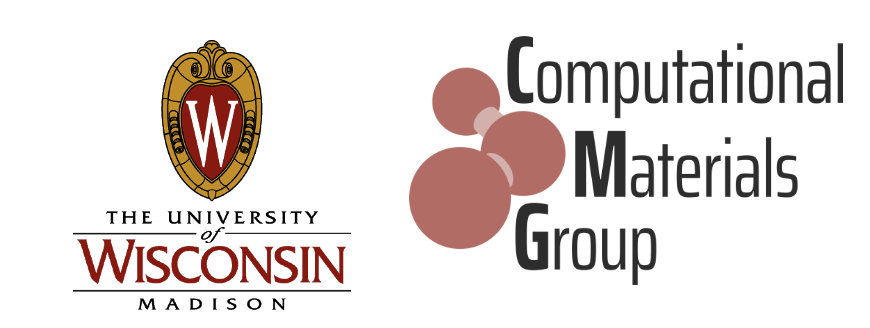

---


## Google Colab notebook for finetuning Mattergen: example of
## conditional generation of high voltage Na-battery materials

# Part 1: Installation and setup

To begin, we need to install needed python dependencies to run Mattergen

In [1]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [2]:
# These installs take about 1 minute

!uv pip install torch==2.4.1 torchvision==0.19.1
!uv pip install pymatgen mp_api emmet-core py3Dmol hydra-core pytorch-lightning==2.0.6 fire ase numpy==1.26.4

Using Python 3.12.11 environment at: /usr
Resolved 26 packages in 297ms
Prepared 14 packages in 51.36s
Uninstalled 14 packages in 865ms
Installed 14 packages in 331ms
 - nvidia-cublas-cu12==12.6.4.1
 + nvidia-cublas-cu12==12.1.3.1
 - nvidia-cuda-cupti-cu12==12.6.80
 + nvidia-cuda-cupti-cu12==12.1.105
 - nvidia-cuda-nvrtc-cu12==12.6.77
 + nvidia-cuda-nvrtc-cu12==12.1.105
 - nvidia-cuda-runtime-cu12==12.6.77
 + nvidia-cuda-runtime-cu12==12.1.105
 - nvidia-cudnn-cu12==9.10.2.21
 + nvidia-cudnn-cu12==9.1.0.70
 - nvidia-cufft-cu12==11.3.0.4
 + nvidia-cufft-cu12==11.0.2.54
 - nvidia-curand-cu12==10.3.7.77
 + nvidia-curand-cu12==10.3.2.106
 - nvidia-cusolver-cu12==11.7.1.2
 + nvidia-cusolver-cu12==11.4.5.107
 - nvidia-cusparse-cu12==12.5.4.2
 + nvidia-cusparse-cu12==12.1.0.106
 - nvidia-nccl-cu12==2.27.3
 + nvidia-nccl-cu12==2.20.5
 - nvidia-nvtx-cu12==12.6.77
 + nvidia-nvtx-cu12==12.1.105
 - torch==2.8.0+cu126
 + torch==2.4.1
 - torchvision==0.23.0+cu126
 + torchvision==0.19.1
 - triton==3.4

Next, we specifically deal with the torch dependencies as they can be tricky

In [3]:
# These installs take about 45 seconds

import torch
print(torch.__version__)

!pip uninstall torch-scatter torch-sparse torch-geometric torch-cluster  --y
!pip install torch-scatter -f https://data.pyg.org/whl/torch-{torch.__version__}.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-{torch.__version__}.html
!pip install torch-cluster -f https://data.pyg.org/whl/torch-{torch.__version__}.html
!pip install git+https://github.com/pyg-team/pytorch_geometric.git

2.4.1+cu121
Looking in links: https://data.pyg.org/whl/torch-2.4.1+cu121.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 103.9 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.4.1+cu121.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 27.7 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.4.1+cu121.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 25.7 MB/s eta 0:00:00
  Cloning https://github.com/pyg-team/pytorch_geometric.git to /tmp/pip-req-build-wwkk5ywh
  Running command git clone --filter=blob:none --quiet https://github.com/pyg-team/pytorch_geometric.git /tmp/pip-req-build-wwkk5ywh
  Resolved https://github.com/pyg-team/pytorch_geometric.git to commit b2c3941c610207f9cdc21df7694dfb5a8550ed2a
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for torch-geometric: filename=torch_geometric-2.7.0-py3-none-any

There is no PyPi release of Mattergen, so we clone it from Github.
We need to run the install so the shortcuts to the scripts work

In [4]:
!git clone https://github.com/microsoft/mattergen

import os
os.chdir('/content/mattergen')
!pip install -e . --no-deps #Issues with installing deps, but this is needed to get script shortcuts working

Cloning into 'mattergen'...
remote: Enumerating objects: 1660, done.
remote: Counting objects: 100% (407/407), done.
remote: Compressing objects: 100% (164/164), done.
remote: Total 1660 (delta 302), reused 243 (delta 243), pack-reused 1253 (from 2)
Receiving objects: 100% (1660/1660), 3.38 MiB | 16.72 MiB/s, done.
Resolving deltas: 100% (657/657), done.
Obtaining file:///content/mattergen
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for mattergen (pyproject.toml) ... done
  Created wheel for mattergen: filename=mattergen-1.0.3-0.editable-py3-none-any.whl size=75506 sha256=97f5c3a948b7f733757866344c0afaf7103c9569e84f16487e9b273ebd128fbd
  Stored in directory: /tmp/pip-ephem-wheel-cache-0huvl3wl/wheels/70/14/e2/3c7000c361845cb5a1e2a263829b656dff268c57d16f9718d1
Successfully built mattergen


Now that everything is installed, we need to restart the runtime prior to importing packages so the new install can take effect

In [ ]:
# HERE- Need to do Runtime -> Restart Session in order for new installs to take effect

In [1]:
import joblib
import pandas as pd
import numpy as np
import os
from pymatgen.core import Structure, Composition
import py3Dmol
import matplotlib.pyplot as plt

import sys
sys.path.append('mattergen')
sys.path.append('/content/mattergen')

# Part 2: Obtaining the data used for Mattergen finetuning

There is a saved data file in the Google Drive which contains the calculated
average voltage of Na insertion. The data were obtained by screening materials
from the Materials Project and calculting the voltage using a Universal
Machine Learning Interatomic Potential (U-MLIP).

Note: if the data doesn't load for you because Colab says the file doesn't exist, make sure you have added the TMS folder to your MyDrive shortcut. In your Google Drive, navigate to the TMS folder, right-click on the folder name, then do Organize -> Add Shortcut -> All Locations -> MyDrive -> Add

In [2]:
import joblib, os
d = '/content/drive/MyDrive/TMS AI4MSE for DEMO 2025-10-28/Sec 3 MatterGen/'
df = joblib.load(os.path.join(d, 'mp_Na_eqV2.pkl'))

df.head()

,index,"Relaxed structure, full","Relaxed structure, empty","Relaxed structure, ref","Relaxed energy, full","Relaxed energy, empty","Relaxed energy, ref","Relaxed volume, full","Relaxed volume, empty",Average voltage (V/ion),mp_id,Composition,Structure
0,0,"{'@module': 'pymatgen.core.structure', '@class...","{'@module': 'pymatgen.core.structure', '@class...","{'@module': 'pymatgen.core.structure', '@class...",-47.144470,-42.739342,-2.612235,86.925992,82.302897,3.099011,mp-1002571-GGA+U,NaMn2O4,"[[ 1.4537295 -0.858677 2.8019015] Na, [0. 0...."
1,0,"{'@module': 'pymatgen.core.structure', '@class...","{'@module': 'pymatgen.core.structure', '@class...","{'@module': 'pymatgen.core.structure', '@class...",-347.147003,-342.174774,-2.612235,580.632428,580.309435,3.666111,mp-1003635-GGA+U,NaMn16O32,"[[4.97042764 4.96925164 4.40963713] Na, [6.467..."
2,0,"{'@module': 'pymatgen.core.structure', '@class...","{'@module': 'pymatgen.core.structure', '@class...","{'@module': 'pymatgen.core.structure', '@class...",-360.532379,-342.138519,-2.612235,592.342169,578.011476,3.292347,mp-1003636-GGA+U,NaMn4O8,"[[3.75601408 7.43825464 1.65457529] Na, [ 5.16..."
3,0,"{'@module': 'pymatgen.core.structure', '@class...","{'@module': 'pymatgen.core.structure', '@class...","{'@module': 'pymatgen.core.structure', '@class...",-351.932495,-342.103943,-2.612235,585.379022,583.089731,3.608158,mp-1003638-GGA+U,NaMn8O16,"[[-4.9288659 5.00872719 -1.47329048] Na, [-9..."
4,0,"{'@module': 'pymatgen.core.structure', '@class...","{'@module': 'pymatgen.core.structure', '@class...","{'@module': 'pymatgen.core.structure', '@class...",-93.682617,-84.215996,-2.612235,162.257705,136.842690,3.427193,mp-1003766-GGA+U,NaMn2O4,"[[1.46205272 2.17082951 8.89991039] Na, [1.462..."


The data file contains U-MLIP relaxed structures and average voltages for 2288 materials. Let's plot a histogram of the computed average voltages to see their distribution:

In [3]:
def plot_voltage_histogram(df, dataset='MP', ion='Na'):
    bins = np.arange(0, 10, 0.2)

    # Matterverse avg voltage has a bunch of negative values- remove them!
    df = df[df['Average voltage (V/ion)'] >=0]

    plt.clf()

    plt.hist(bins=bins, x=df['Average voltage (V/ion)'], color='red', edgecolor='black', alpha=0.5, label='EquiformerV2')

    plt.xlabel('Average voltage (V/Na)', fontsize=14)
    plt.xticks(fontsize=12)
    plt.ylabel('Number of occurrences', fontsize=14)
    plt.yticks(fontsize=12)
    plt.legend(loc='best')
    plt.savefig('Voltage_histogram_'+dataset+'_'+ion+'.png', dpi=300, bbox_inches='tight')

    vals = df['Average voltage (V/ion)']
    print('EquiformerV2 stats')
    print(np.mean(vals), np.std(vals), min(vals), max(vals))

    return

EquiformerV2 stats
4.1346677545044805 0.9164283551284464 0.5237773656845093 6.9161494970321655


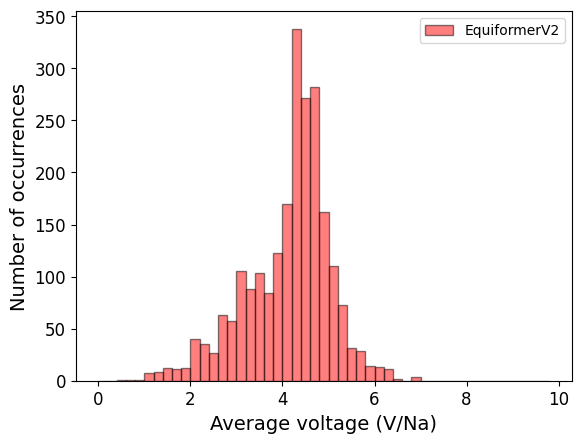

In [4]:
plot_voltage_histogram(df)

As we can see, the average voltage is around 4.1 V/Na, with numerous instances of high voltage materials.

Next, we can use a function to make a 3D visualization of a structure, which will also come in handy later for visualizing some generated structures from Mattergen

In [5]:
def show_structure_3d(struct, supercell=(1,1,1), style="ballstick", width=700, height=500, spin=False, labels=False):
    s = struct.copy()
    if supercell != (1,1,1):
        s.make_supercell(supercell)
    cif_str = s.to(fmt="cif")

    view = py3Dmol.view(width=width, height=height)
    view.addModel(cif_str, "cif")
    view.addUnitCell()
    view.setBackgroundColor("white")

    if style == "ballstick":
        view.setStyle({"sphere": {"scale": 0.23}, "stick": {"radius": 0.15}})
    elif style == "licorice":
        view.setStyle({"stick": {}})
    elif style == "vdw":
        view.setStyle({"sphere": {"scale": 0.3}})
    else:
        view.setStyle({"stick": {}})

    if labels:
        for site in s.sites:
            x, y, z = map(float, site.coords)  # cartesian Å
            view.addLabel(
                site.specie.symbol,
                {"position": {"x": x, "y": y, "z": z},
                  "fontSize": 12, "fontColor": "black",
                 "alignment": "center", "offset": {"x": 0, "y": 0},
                  "backgroundOpacity": 0.0}  # no background box
            )

    view.zoomTo()
    if spin:
        view.spin(True)
    return view.show()


In [6]:
# Visualize (change supercell/style as needed)
struct = df['Structure'].iloc[0]
print(struct.reduced_formula)
show_structure_3d(struct, supercell=(2, 2, 2), style="ballstick", labels=True)

NaMn2O4


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

# Part 3: Copy the pre-made data and already modified mattergen code from the Google Drive

In [7]:
# Copy the modified mattergen code from the Google Drive

!cp '/content/drive/MyDrive/TMS AI4MSE for DEMO 2025-10-28/Sec 3 MatterGen/mattergen.tar.gz' '/content'

In [8]:
# Remove the previously cloned repo

!rm -r mattergen

In [9]:
# Unpack the modified repo

!tar -xzvf mattergen.tar.gz

mattergen/
mattergen/SECURITY.md
mattergen/assets/
mattergen/assets/datasets_venn_diagram.png
mattergen/assets/MatterGenlogo_.png
mattergen/.git/
mattergen/.git/HEAD
mattergen/.git/objects/
mattergen/.git/objects/pack/
mattergen/.git/objects/pack/pack-8fc4b3f1eb56e7ec8877a9c046a2e7183bb827e6.idx
mattergen/.git/objects/pack/pack-8fc4b3f1eb56e7ec8877a9c046a2e7183bb827e6.pack
mattergen/.git/objects/info/
mattergen/.git/logs/
mattergen/.git/logs/HEAD
mattergen/.git/logs/refs/
mattergen/.git/logs/refs/remotes/
mattergen/.git/logs/refs/remotes/origin/
mattergen/.git/logs/refs/remotes/origin/HEAD
mattergen/.git/logs/refs/heads/
mattergen/.git/logs/refs/heads/main
mattergen/.git/description
mattergen/.git/config
mattergen/.git/info/
mattergen/.git/info/exclude
mattergen/.git/lfs/
mattergen/.git/lfs/incomplete/
mattergen/.git/lfs/tmp/
mattergen/.git/lfs/tmp/2126704037
mattergen/.git/lfs/tmp/428755528
mattergen/.git/lfs/tmp/1653481516
mattergen/.git/lfs/tmp/735251299
mattergen/.git/lfs/tmp/13402

# Part 4: Finetuning Mattergen on Na voltages

We are now ready to do the actual finetuning! Here, we only finetune for 10 epochs, so you can get a feel for the process. The resulting model will not be very good but can still be used to generate new structures. Below, we also show an example of copying another finetuned model which should provide improved results

In [10]:
os.chdir('/content/mattergen')

!mattergen-finetune adapter.pretrained_name=mattergen_base data_module=mp_20 \
  +lightning_module/diffusion_module/model/property_embeddings@adapter.adapter.property_embeddings_adapt.voltage=voltage \
  +lightning_module/diffusion_module/model/property_embeddings@adapter.adapter.property_embeddings_adapt.chemical_system=chemical_system \
  ~trainer.logger data_module.properties=["voltage","chemical_system"] trainer.accelerator=gpu trainer.devices=1 \
  trainer.max_epochs=10

MODELS_PROJECT_ROOT: /content/mattergen/mattergen
/usr/local/lib/python3.12/dist-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'finetune': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/hydra/_internal/hydra.py:119: UserWarning: Future Hydra versions will no longer change working directory at job runtime by default.
See https://hydra.cc/docs/1.2/upgrades/1.1_to_1.2/changes_to_job_working_dir/ for more information.
  ret = run_job(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
checkpoints/mattergen_base/checkpoints/l(…): 100% 461M/461M [00:07<00:00, 64.3MB/s]
config.yaml: 5.49kB [00:00, 15.1MB/s]
/content/mattergen/mattergen/scripts/finetune.py:93: FutureWarning: You are using `torch.load` with `weights_only=F

Below are instructions to either (1) use the model you just finetuned or (2) use the previously finetuned model from Google Drive. Some files need to be moved around before we can do the generation

In [12]:
# NOTE: if you get an error about a directory not existing, run the cell again

# When training is complete, we can use the fine-tuned model to generate new structures.
# Note, the model is not going to be very good since we didn't train for very long.
# Alternatively, you can copy a trained model from the Google Drive (shown below)

if not os.getcwd() == '/content/mattergen':
    os.chdir('/content/mattergen')

# First, need to copy the saved checkpoint in the outputs/singlerun/{TODAY'S DATE}/checkpoints folder
# to mattergen/checkpoints/{YOUR MODEL NAME}

# For example (note you will need to update the date when you run it)
#!cp -r outputs/singlerun/2025-09-04/16-15-50/lightning_logs/version_0/ mattergen/checkpoints/
#!mv mattergen/checkpoints/version_0 mattergen/checkpoints/my_new_model

#Use --model-path = 'mattergen/checkpoints/my_new_model'

# Alternatively, copy another model from Google Drive which will be better
!cp -r /content/drive/MyDrive/TMS\ AI4MSE\ for\ DEMO\ 2025-10-28/Sec\ 3\ MatterGen/chemical_system_energy_above_hull_voltage.zip mattergen/checkpoints/
!unzip mattergen/checkpoints/chemical_system_energy_above_hull_voltage.zip
!mv checkpoints/ chemical_system_energy_above_hull_voltage
!mv config.yaml chemical_system_energy_above_hull_voltage
!mv chemical_system_energy_above_hull_voltage mattergen/checkpoints
!mkdir mattergen/checkpoints/chemical_system_energy_above_hull_voltage/checkpoints
!mv mattergen/checkpoints/chemical_system_energy_above_hull_voltage/last.ckpt mattergen/checkpoints/chemical_system_energy_above_hull_voltage/checkpoints
!mv mattergen/checkpoints/chemical_system_energy_above_hull_voltage/epoch=134-loss_val=0.21.ckpt mattergen/checkpoints/chemical_system_energy_above_hull_voltage/checkpoints

#Use --model-path = 'mattergen/checkpoints/chemical_system_energy_above_hull_voltage'


Archive:  mattergen/checkpoints/chemical_system_energy_above_hull_voltage.zip
Written using ZipTricks 5.6.0
   creating: OLD/
   creating: OLD/checkpoints/
  inflating: OLD/checkpoints/last.ckpt  
  inflating: OLD/config.yaml         
   creating: checkpoints/
  inflating: checkpoints/epoch=134-loss_val=0.21.ckpt  
  inflating: checkpoints/last.ckpt   
  inflating: config.yaml             


# Part 5: Generating new materials with a finetuned Mattergen model

Now we can finally generate new structures! This process does take some time even on a GPU- about 1 minute per structure. Using the settings here will create 16 new structures and take roughly 15 minutes. You can reduce batch_size to make more or fewer structures.

In [13]:
# Note that the present setting takes ~7 minutes for generation. Replace "my_new_model"
# with "chemical_system_energy_above_hull_voltage" if using the pre-trained
# model from Google Drive

!mattergen-generate results --model-path=mattergen/checkpoints/chemical_system_energy_above_hull_voltage --batch_size=8 \
  --properties_to_condition_on="{'voltage': 4.0, 'chemical_system': 'Na-Mn-C-P-O'}" \
  --diffusion_guidance_factor=2.0 --num_batches=1

MODELS_PROJECT_ROOT: /content/mattergen/mattergen

Model config:
/content/mattergen/mattergen/common/utils/data_classes.py:96: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize_config_dir(str(self.model_path)):
adapter:
  adapter:
    _target_: mattergen.adapter.GemNetTAdapter
    atom_type_diffusion: mask
    denoise_atom_types: true
    gemnet:
      _target_: mattergen.common.gemnet.gemnet_ctrl.GemNetTCtrl
      atom_embedding:
        _target_: mattergen.common.gemnet.layers.embedding_block.AtomEmbedding
        emb_size: 512
        with_mask_type: true
      condition_on_adapt:
      - voltage
      - energy_above_hull
      - chemical_system
      cutoff: 7.0
      emb_size_atom: 512
      emb_size_edge: 512
      latent_dim: 512
      max_cell_images_per_dim: 5
      max_neighbors: 50
      num_blocks: 4
      num_targets: 1
      otf_graph: true
      regress_

In [ ]:
# Now that we have some generated structures, we can open them and examine the
# resulting compositions and structures

!unzip results/generated_crystals_cif.zip

Alternatively, we can copy a folder of generated structures from a previous run

In [14]:
!rm -r generated_crystals_cif
!cp /content/drive/MyDrive/TMS\ AI4MSE\ for\ DEMO\ 2025-10-28/Sec\ 3\ MatterGen/generated_crystals_cif.zip .
!unzip generated_crystals_cif.zip

rm: cannot remove 'generated_crystals_cif': No such file or directory
Archive:  generated_crystals_cif.zip
 extracting: gen_0.cif               
 extracting: gen_1.cif               
 extracting: gen_2.cif               
 extracting: gen_3.cif               
 extracting: gen_4.cif               
 extracting: gen_5.cif               
 extracting: gen_6.cif               
 extracting: gen_7.cif               
 extracting: gen_8.cif               
 extracting: gen_9.cif               
 extracting: gen_10.cif              
 extracting: gen_11.cif              
 extracting: gen_12.cif              
 extracting: gen_13.cif              
 extracting: gen_14.cif              
 extracting: gen_15.cif              
 extracting: gen_16.cif              
 extracting: gen_17.cif              
 extracting: gen_18.cif              
 extracting: gen_19.cif              
 extracting: gen_20.cif              
 extracting: gen_21.cif              
 extracting: gen_22.cif              
 extracting: gen_23

# Part 6: Visualize your generated structures and calculate their average voltage with a U-MLIP

In [15]:
# Visualize (change supercell/style as needed)

from pymatgen.core import Structure
struct = Structure.from_file("gen_71.cif")
print(struct.reduced_formula)
show_structure_3d(struct, supercell=(2, 2, 2), style="ballstick", spin=False, labels=True)

NaMn(CO3)2


/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:2945: UserWarning: Site labels are not unique, which is not compliant with the CIF spec (https://www.iucr.org/__data/iucr/cifdic_html/1/cif_core.dic/Iatom_site_label.html):`['Na1', 'Na1', 'Na1', 'Na1', 'Na1', 'Na1', 'Na1', 'Na1', 'Mn1', 'Mn1', 'Mn1', 'Mn1', 'Mn1', 'Mn1', 'Mn1', 'Mn1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'O1', 'O1', 'O1', 'O1', 'O1', 'O1', 'O1', 'O1', 'O2', 'O2', 'O2', 'O2', 'O2', 'O2', 'O2', 'O2', 'O3', 'O3', 'O3', 'O3', 'O3', 'O3', 'O3', 'O3', 'O4', 'O4', 'O4', 'O4', 'O4', 'O4', 'O4', 'O4', 'O5', 'O5', 'O5', 'O5', 'O5', 'O5', 'O5', 'O5', 'O6', 'O6', 'O6', 'O6', 'O6', 'O6', 'O6', 'O6']`.
  writer: Any = CifWriter(self, **kwargs)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Need to install a U-MLIP. Here, we will use CHGNet


In [16]:
!pip install chgnet

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.7/13.7 MB 30.1 MB/s eta 0:00:00
  Created wheel for nvidia-ml-py3: filename=nvidia_ml_py3-7.352.0-py3-none-any.whl size=19172 sha256=6e8b682d3405b0025c069facf9264bb19ee98b00996f3203aefe65c78df09271
  Stored in directory: /root/.cache/pip/wheels/6e/65/79/33dee66cba26e8204801916dfee7481bccfd22905ebb841fe5
Successfully built nvidia-ml-py3


We can use a Universal Machine Learning Potential (U-MLIP) to relax the generated structure and get a total energy. By calculating the energies with and without Na, we can get an average Na voltage

In [17]:
from chgnet.model import StructOptimizer
from pymatgen.core import Structure, Element
from copy import copy

def relax(s):
    # 1) Load your starting structure
    #s = Structure.from_file(cif_file)

    # 2) Create the CHGNet relaxer (uses GPU if available; CPU otherwise)
    relaxer = StructOptimizer()  # you can pass device="cuda" or "cpu"

    # 3) Relax (tune fmax for tighter/looser forces; steps is a hard cap)
    result = relaxer.relax(
        s,
        fmax=0.05,        # eV/Å target force (typical: 0.05–0.1)
        steps=1000,       # max optimizer steps
        relax_cell=True,  # True = relax lattice + ions; False = fixed cell
        verbose=True
    )

    relaxed = result["final_structure"]           # pymatgen.Structure
    E_final = result["trajectory"].energies[-1]   # eV

    return relaxed, E_final

def drop_element(struct: Structure, element: str | Element) -> Structure:
    #el = Element(element) if not isinstance(element, Element) else element
    idx_to_remove = []
    for i, site in enumerate(struct.sites):
        # site.species is a dict-like {Species: occupancy}; Species.element is an Element
        #if any(getattr(sp, "element", None) == el for sp in site.species.keys()):
        if site.specie == Element(element):
            idx_to_remove.append(i)
    print(idx_to_remove)
    new = struct.copy()
    if idx_to_remove:
        new.remove_sites(idx_to_remove)
    return new

def get_voltage(ion, final_structure_full, final_structure_empty, final_structure_ref, final_energy_full, final_energy_empty, final_energy_ref):
    #from copy import copy
    final_structure_full_copy = copy(final_structure_full)
    final_structure_empty_copy = copy(final_structure_empty)
    num_ref = final_structure_ref.composition.as_dict()[ion]
    #before = len(final_structure_full_copy)
    final_structure_full_copy.remove_species([ion]) # Needed to get ratio of fu's
    final_structure_empty_copy.remove_species([ion]) # Needed to get ratio of fu's
    #after = len(final_structure_full_copy)
    #num_fu_full = final_structure_full.composition.num_atoms / final_structure_full.composition.reduced_composition.num_atoms
    #num_fu_empty = final_structure_empty.composition.num_atoms / final_structure_empty.composition.reduced_composition.num_atoms
    fu_ratio = final_structure_full_copy.composition.num_atoms / final_structure_empty_copy.composition.num_atoms
    #num_int = final_structure_full.composition.reduced_composition.as_dict()['Na']/num_fu_full - final_structure_empty.composition.reduced_composition.as_dict()['Na']/num_fu_empty
    #num_int = before - after
    Na_full = final_structure_full.composition.as_dict()[ion]
    try:
        Na_empty = final_structure_empty.composition.as_dict()[ion]*fu_ratio
    except:
        Na_empty = 0
    num_int = Na_full - Na_empty
    #print('ref, int, furatio')
    #print(num_ref, num_int, fu_ratio)
    if ion in ['Mg', 'Ca']:
        multiplier = 2
    else:
        multiplier = 1
    voltage = -1*(final_energy_full - fu_ratio*final_energy_empty - (num_int*final_energy_ref)/num_ref) / (num_int*multiplier)
    return voltage


We select one of our generated structures, and do a full relaxation of the generated structure (assumed to be filled with Na, discharge state) and a version with all Na removed (the charged state), and calculate the average Na voltage

In [18]:
# Relax the full cell
s = Structure.from_file("gen_71.cif")
s_full, E_final = relax(s)
print("Final CHGNet energy (eV):", E_final)

# Relax the Na empty cell
s_empty = drop_element(s, element='Na')
s_empty, E_final_empty = relax(s_empty)
print("Final CHGNet energy of empty cell (eV):", E_final_empty)

# Open Na ref structure and relax
s_ref = Structure.from_file("/content/drive/MyDrive/TMS AI4MSE for DEMO 2025-10-28/Sec 3 MatterGen/Na.cif")
s_ref, E_final_ref = relax(s_ref)
print("Final CHGNet energy of ref cell (eV):", E_final_ref)

# Get the voltage
voltage = get_voltage('Na', s_full, s_empty, s_ref, E_final, E_final_empty, E_final_ref)
print("Na voltage:", voltage)

CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cuda
      Step     Time          Energy          fmax
FIRE:    0 15:19:57      -78.167958        0.316465
FIRE:    1 15:19:57      -78.171892        0.252948
FIRE:    2 15:19:57      -78.175063        0.187424
FIRE:    3 15:19:58      -78.176956        0.253286
FIRE:    4 15:19:58      -78.179498        0.186719
FIRE:    5 15:19:58      -78.181257        0.116324
FIRE:    6 15:19:59      -78.182087        0.217995
FIRE:    7 15:19:59      -78.182569        0.191885
FIRE:    8 15:19:59      -78.183336        0.145097
FIRE:    9 15:19:59      -78.184114        0.094125
FIRE:   10 15:19:59      -78.184690        0.089446
FIRE:   11 15:20:00      -78.185105        0.110923
FIRE:   12 15:20:00      -78.185568        0.141508
FIRE:   13 15:20:00      -78.186159        0.137873
FIRE:   14 15:20:00      -78.186860        0.107636
FIRE:   15 15:20:00      -78.187599        0.083009
FIRE:   16 15:20:01      -78.188272        0

/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]


FIRE:    1 15:20:32       -2.588426        0.075118
FIRE:    2 15:20:32       -2.588553        0.072621
FIRE:    3 15:20:32       -2.588734        0.068926
FIRE:    4 15:20:32       -2.588959        0.064100
FIRE:    5 15:20:32       -2.589217        0.058240
FIRE:    6 15:20:33       -2.589494        0.051498
FIRE:    7 15:20:33       -2.589776        0.044074
Final CHGNet energy of ref cell (eV): -2.589776039123535
Na voltage: 4.276276111602783


By using the gen_71.cif structure from the stuctures generated previously and available on Google Drive, (discharge composition NaMn(CO3)2), we get a Na voltage of 4.28 V/Na, which is interesting!

We note there will be generated structures that don't have relevant elements or whose properties don't match the target you're going for, but it is fairly fast to generate and evaluate new potential structures.